Задача:

1. Реализовать REINFORCE с baseline.
2. Обучить агента поднимать свободный конец нижнего звена выше заданной высоты.
3. Достичь средней награды **-100 или выше**.

В `Acrobot-v1`:

```text
Состояние: 6 признаков
Действия: 3
Награда: -1 за каждый шаг до достижения цели
```

## Установка

Используем актуальный `Gymnasium` и среду `Acrobot-v1`.

In [1]:
%pip install -q "gymnasium[classic-control]>=1.0,<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 36.8 MB/s eta 0:00:00


## Импорты

In [2]:
# Импорты

import copy
import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.distributions import Categorical


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Gymnasium:",
    gym.__version__
)

print(
    "PyTorch:",
    torch.__version__
)

print(
    "Device:",
    DEVICE
)

Gymnasium: 1.3.0
PyTorch: 2.11.0+cu128
Device: cuda


## Создание среды

У `Acrobot-v1`:

- наблюдение имеет размерность 6;
- доступно 3 действия;
- эпизод завершается, когда свободный конец второго звена
  поднимается выше целевой высоты;
- максимальная длина стандартного эпизода — 500 шагов.

In [3]:
# Acrobot-v1

ENV_ID = "Acrobot-v1"


env = gym.make(
    ENV_ID
)


N_STATE = env.observation_space.shape[
    0
]

N_ACTION = env.action_space.n


print(
    "Среда:",
    ENV_ID
)

print(
    "Размер состояния:",
    N_STATE
)

print(
    "Количество действий:",
    N_ACTION
)

print(
    "Observation space:",
    env.observation_space
)

print(
    "Action space:",
    env.action_space
)


assert N_STATE == 6
assert N_ACTION == 3

Среда: Acrobot-v1
Размер состояния: 6
Количество действий: 3
Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Action space: Discrete(3)


## Нормализация состояния

Первые четыре значения состояния — синусы и косинусы углов,
они уже находятся в диапазоне `[-1, 1]`.

Последние два значения — угловые скорости.
Нормализуем их по физическим ограничениям среды.

In [4]:
# Нормализация состояния

STATE_SCALE = np.array(
    [
        1.0,
        1.0,
        1.0,
        1.0,
        4.0 * np.pi,
        9.0 * np.pi,
    ],
    dtype=np.float32,
)


def normalize_state(
    state,
):
    state = np.asarray(
        state,
        dtype=np.float32,
    )

    return (
        state
        / STATE_SCALE
    )

## Высота свободного конца

Состояние содержит:

```text
cos(theta1)
sin(theta1)
cos(theta2)
sin(theta2)
```

Высоту свободного конца второго звена можно получить без восстановления углов:

```text
height =
    -cos(theta1)
    -cos(theta1 + theta2)
```

Цель среды достигается при:

```text
height > 1.0
```

In [5]:
# Высота конца второго звена

def acrobot_height(
    state,
):

    cos_1 = state[0]
    sin_1 = state[1]

    cos_2 = state[2]
    sin_2 = state[3]


    cos_1_plus_2 = (
        cos_1 * cos_2
        - sin_1 * sin_2
    )


    height = (
        -cos_1
        - cos_1_plus_2
    )


    return float(
        height
    )

Сеть Actor получает состояние и выдаёт logits для трёх действий.

Из logits создаём распределение `Categorical`,
из которого во время обучения выбирается действие.

In [6]:
# Policy Network

class PolicyNetwork(
    nn.Module
):
    def __init__(
        self,
        n_state,
        n_action,
        n_hidden=128,
    ):
        super().__init__()


        self.model = nn.Sequential(
            nn.Linear(
                n_state,
                n_hidden,
            ),
            nn.ReLU(),

            nn.Linear(
                n_hidden,
                n_hidden,
            ),
            nn.ReLU(),

            nn.Linear(
                n_hidden,
                n_action,
            ),
        )


    def forward(
        self,
        state,
    ):
        return self.model(
            state
        )

## Value Network — baseline

Baseline оценивает ценность текущего состояния:

```text
V(s)
```

Именно её вычитаем из накопленного дохода:

```text
advantage = G - V(s)
```

In [7]:
# Value Network

class ValueNetwork(
    nn.Module
):
    def __init__(
        self,
        n_state,
        n_hidden=128,
    ):
        super().__init__()


        self.model = nn.Sequential(
            nn.Linear(
                n_state,
                n_hidden,
            ),
            nn.ReLU(),

            nn.Linear(
                n_hidden,
                n_hidden,
            ),
            nn.ReLU(),

            nn.Linear(
                n_hidden,
                1,
            ),
        )


    def forward(
        self,
        state,
    ):
        return (
            self.model(
                state
            )
            .squeeze(
                -1
            )
        )

## Накопленное дисконтированное вознаграждение

Для каждого момента времени считаем:

```text
G_t =
    r_t
    + gamma * r_(t+1)
    + gamma^2 * r_(t+2)
    + ...
```

In [8]:
# Discounted returns

def discounted_returns(
    rewards,
    gamma,
):

    returns = []

    G = 0.0


    for reward in reversed(
        rewards
    ):

        G = (
            float(
                reward
            )
            + gamma
            * G
        )


        returns.append(
            G
        )


    returns.reverse()


    return torch.tensor(
        returns,
        dtype=torch.float32,
        device=DEVICE,
    )

## Один обучающий эпизод

Во время эпизода сохраняем:

- `log_prob` выбранного действия;
- энтропию политики;
- оценку `V(s)`;
- награду.

После завершения эпизода вычисляем returns и advantage.

In [9]:
# Один обучающий эпизод

def train_episode(
    env,
    policy,
    value_net,
    policy_optimizer,
    value_optimizer,
    gamma=0.99,
    entropy_coef=0.001,
    seed=None,
):

    state, info = env.reset(
        seed=seed
    )


    log_probs = []

    entropies = []

    values = []

    rewards = []


    total_reward = 0.0

    max_height = (
        acrobot_height(
            state
        )
    )


    while True:

        normalized = normalize_state(
            state
        )


        state_tensor = torch.tensor(
            normalized,
            dtype=torch.float32,
            device=DEVICE,
        )


        logits = policy(
            state_tensor
        )


        distribution = Categorical(
            logits=logits
        )


        action = distribution.sample()


        value = value_net(
            state_tensor
        )


        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(
            int(
                action.item()
            )
        )


        log_probs.append(
            distribution.log_prob(
                action
            )
        )

        entropies.append(
            distribution.entropy()
        )

        values.append(
            value
        )

        rewards.append(
            float(
                reward
            )
        )


        total_reward += float(
            reward
        )


        max_height = max(
            max_height,
            acrobot_height(
                next_state
            ),
        )


        state = next_state


        if (
            terminated
            or truncated
        ):
            break


    returns = discounted_returns(
        rewards,
        gamma,
    )


    values = torch.stack(
        values
    )


    log_probs = torch.stack(
        log_probs
    )


    entropies = torch.stack(
        entropies
    )


    # Baseline:
    # A = G - V(s)
    advantages = (
        returns
        - values.detach()
    )


    # Нормализация advantage
    # уменьшает дисперсию градиента.
    if len(
        advantages
    ) > 1:

        advantages = (
            advantages
            - advantages.mean()
        ) / (
            advantages.std()
            + 1e-8
        )


    policy_loss = -(
        log_probs
        * advantages
    ).mean()


    # Небольшая энтропийная добавка
    # помогает исследованию среды.
    policy_loss -= (
        entropy_coef
        * entropies.mean()
    )


    value_loss = F.smooth_l1_loss(
        values,
        returns,
    )


    policy_optimizer.zero_grad()

    policy_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        policy.parameters(),
        max_norm=1.0,
    )

    policy_optimizer.step()


    value_optimizer.zero_grad()

    value_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        value_net.parameters(),
        max_norm=1.0,
    )

    value_optimizer.step()


    return {
        "reward": total_reward,

        "steps": len(
            rewards
        ),

        "max_height": max_height,

        "policy_loss": float(
            policy_loss.item()
        ),

        "value_loss": float(
            value_loss.item()
        ),

        "success": bool(
            max_height > 1.0
        ),
    }

## Обучение REINFORCE с baseline

Цель:

```text
средняя награда последних 100 эпизодов >= -100
```

Для устойчивости сохраняем лучшую найденную модель.

Если критерий достигнут, обучение завершается досрочно.

In [10]:
# Обучение

def train_reinforce_baseline(
    max_episodes=4000,
    gamma=0.99,
    policy_lr=5e-4,
    value_lr=1e-3,
    entropy_coef=0.001,
    seed=SEED,
):

    policy = PolicyNetwork(
        N_STATE,
        N_ACTION,
        n_hidden=128,
    ).to(
        DEVICE
    )


    value_net = ValueNetwork(
        N_STATE,
        n_hidden=128,
    ).to(
        DEVICE
    )


    policy_optimizer = optim.Adam(
        policy.parameters(),
        lr=policy_lr,
    )


    value_optimizer = optim.Adam(
        value_net.parameters(),
        lr=value_lr,
    )


    rewards = []

    heights = []

    successes = []


    best_mean_reward = (
        -float(
            "inf"
        )
    )


    best_policy_state = None

    best_value_state = None


    for episode in range(
        1,
        max_episodes + 1,
    ):

        result = train_episode(
            env=env,
            policy=policy,
            value_net=value_net,
            policy_optimizer=(
                policy_optimizer
            ),
            value_optimizer=(
                value_optimizer
            ),
            gamma=gamma,
            entropy_coef=(
                entropy_coef
            ),
            seed=(
                seed
                + episode
            ),
        )


        rewards.append(
            result[
                "reward"
            ]
        )

        heights.append(
            result[
                "max_height"
            ]
        )

        successes.append(
            int(
                result[
                    "success"
                ]
            )
        )


        if len(
            rewards
        ) >= 100:

            mean_reward = float(
                np.mean(
                    rewards[
                        -100:
                    ]
                )
            )


            if (
                mean_reward
                > best_mean_reward
            ):

                best_mean_reward = (
                    mean_reward
                )

                best_policy_state = (
                    copy.deepcopy(
                        policy.state_dict()
                    )
                )

                best_value_state = (
                    copy.deepcopy(
                        value_net.state_dict()
                    )
                )


            if (
                episode % 100 == 0
            ):

                success_rate = float(
                    np.mean(
                        successes[
                            -100:
                        ]
                    )
                )


                print(
                    f"Эпизод {episode:4d} | "
                    f"mean reward="
                    f"{mean_reward:7.2f} | "
                    f"success="
                    f"{success_rate:.2f} | "
                    f"height="
                    f"{np.mean(heights[-100:]):.2f}"
                )


            # Чуть более строгая граница,
            # чтобы на тесте был запас.
            if (
                mean_reward
                >= -95.0
            ):

                print()
                print(
                    "Критерий обучения достигнут."
                )

                break


    if (
        best_policy_state
        is not None
    ):

        policy.load_state_dict(
            best_policy_state
        )

        value_net.load_state_dict(
            best_value_state
        )


    return {
        "policy": policy,
        "value_net": value_net,
        "rewards": np.asarray(
            rewards,
            dtype=np.float32,
        ),
        "heights": np.asarray(
            heights,
            dtype=np.float32,
        ),
        "successes": np.asarray(
            successes,
            dtype=np.float32,
        ),
        "best_mean_reward": (
            best_mean_reward
        ),
    }

## Запуск обучения

In [11]:
# Жадная проверка политики

@torch.no_grad()
def evaluate_policy(
    policy,
    n_episodes=100,
    seed=10000,
):

    policy.eval()


    rewards = []

    steps_list = []

    heights = []

    successes = []


    for episode in range(
        n_episodes
    ):

        state, info = env.reset(
            seed=(
                seed
                + episode
            )
        )


        total_reward = 0.0

        steps = 0

        max_height = (
            acrobot_height(
                state
            )
        )


        while True:

            normalized = normalize_state(
                state
            )


            state_tensor = torch.tensor(
                normalized,
                dtype=torch.float32,
                device=DEVICE,
            )


            logits = policy(
                state_tensor
            )


            action = int(
                torch.argmax(
                    logits
                ).item()
            )


            (
                next_state,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(
                action
            )


            total_reward += float(
                reward
            )

            steps += 1


            max_height = max(
                max_height,
                acrobot_height(
                    next_state
                ),
            )


            state = next_state


            if (
                terminated
                or truncated
            ):
                break


        rewards.append(
            total_reward
        )

        steps_list.append(
            steps
        )

        heights.append(
            max_height
        )

        successes.append(
            int(
                max_height > 1.0
            )
        )


    policy.train()


    return {
        "mean_reward": float(
            np.mean(
                rewards
            )
        ),

        "std_reward": float(
            np.std(
                rewards
            )
        ),

        "success_rate": float(
            np.mean(
                successes
            )
        ),

        "rewards": np.asarray(
            rewards
        ),

        "steps": np.asarray(
            steps_list
        ),

        "heights": np.asarray(
            heights
        ),
    }

In [12]:
# Обучение до достижения цели

MAX_ATTEMPTS = 3


best_training = None

best_evaluation = None


for attempt in range(
    1,
    MAX_ATTEMPTS + 1,
):

    print()
    print(
        f"Попытка {attempt}"
    )


    training = (
        train_reinforce_baseline(
            max_episodes=4000,
            gamma=0.99,
            policy_lr=5e-4,
            value_lr=1e-3,
            entropy_coef=0.001,
            seed=(
                SEED
                + attempt * 100000
            ),
        )
    )


    evaluation = evaluate_policy(
        training[
            "policy"
        ],
        n_episodes=100,
        seed=(
            20000
            + attempt * 1000
        ),
    )


    print(
        "Тестовая средняя награда:",
        round(
            evaluation[
                "mean_reward"
            ],
            2,
        )
    )


    if (
        best_evaluation is None
        or evaluation[
            "mean_reward"
        ]
        > best_evaluation[
            "mean_reward"
        ]
    ):

        best_training = training

        best_evaluation = evaluation


    if (
        evaluation[
            "mean_reward"
        ]
        >= -100.0
    ):

        print(
            "Цель задания достигнута."
        )

        break


Попытка 1
Эпизод  100 | mean reward=-495.46 | success=0.03 | height=-0.29
Эпизод  200 | mean reward=-496.28 | success=0.05 | height=-0.44
Эпизод  300 | mean reward=-496.32 | success=0.05 | height=-0.55
Эпизод  400 | mean reward=-488.91 | success=0.11 | height=-0.34
Эпизод  500 | mean reward=-470.63 | success=0.34 | height=0.10
Эпизод  600 | mean reward=-464.07 | success=0.38 | height=0.28
Эпизод  700 | mean reward=-409.24 | success=0.69 | height=0.87
Эпизод  800 | mean reward=-266.10 | success=0.97 | height=1.20
Эпизод  900 | mean reward=-205.62 | success=1.00 | height=1.17
Эпизод 1000 | mean reward=-149.58 | success=1.00 | height=1.20
Эпизод 1100 | mean reward=-126.19 | success=0.98 | height=1.20
Эпизод 1200 | mean reward=-117.62 | success=1.00 | height=1.23
Эпизод 1300 | mean reward=-106.08 | success=1.00 | height=1.18
Эпизод 1400 | mean reward=-105.15 | success=1.00 | height=1.21
Эпизод 1500 | mean reward=-105.02 | success=1.00 | height=1.21
Эпизод 1600 | mean reward=-107.67 | succ

## Результат обучения

In [13]:
# Итоговые показатели

policy = best_training[
    "policy"
]

value_net = best_training[
    "value_net"
]


print(
    "Средняя награда:",
    round(
        best_evaluation[
            "mean_reward"
        ],
        2,
    )
)

print(
    "Стандартное отклонение:",
    round(
        best_evaluation[
            "std_reward"
        ],
        2,
    )
)

print(
    "Доля успешных эпизодов:",
    round(
        best_evaluation[
            "success_rate"
        ],
        3,
    )
)


if (
    best_evaluation[
        "mean_reward"
    ]
    >= -100.0
):

    print(
        "Критерий >= -100 выполнен."
    )

else:

    print(
        "Критерий пока не выполнен. "
        "Можно увеличить max_episodes."
    )

Средняя награда: -92.1
Стандартное отклонение: 23.19
Доля успешных эпизодов: 1.0
Критерий >= -100 выполнен.


## График обучения

Показываем:

- награду за эпизод;
- скользящее среднее за 100 эпизодов;
- целевую линию `-100`.

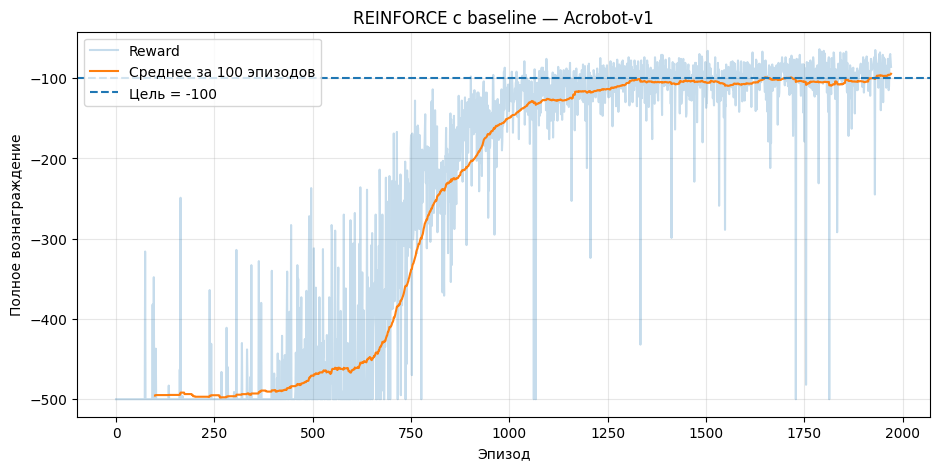

In [14]:
# График награды

rewards = best_training[
    "rewards"
]


window = 100


moving_average = np.convolve(
    rewards,
    np.ones(
        window
    ) / window,
    mode="valid",
)


plt.figure(
    figsize=(
        11,
        5,
    )
)


plt.plot(
    rewards,
    alpha=0.25,
    label="Reward",
)


plt.plot(
    np.arange(
        window - 1,
        len(
            rewards
        ),
    ),
    moving_average,
    label="Среднее за 100 эпизодов",
)


plt.axhline(
    -100,
    linestyle="--",
    label="Цель = -100",
)


plt.xlabel(
    "Эпизод"
)

plt.ylabel(
    "Полное вознаграждение"
)

plt.title(
    "REINFORCE с baseline — Acrobot-v1"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

## График высоты

Проверяем, научился ли агент действительно поднимать свободный конец
второго звена выше целевой высоты `1.0`.

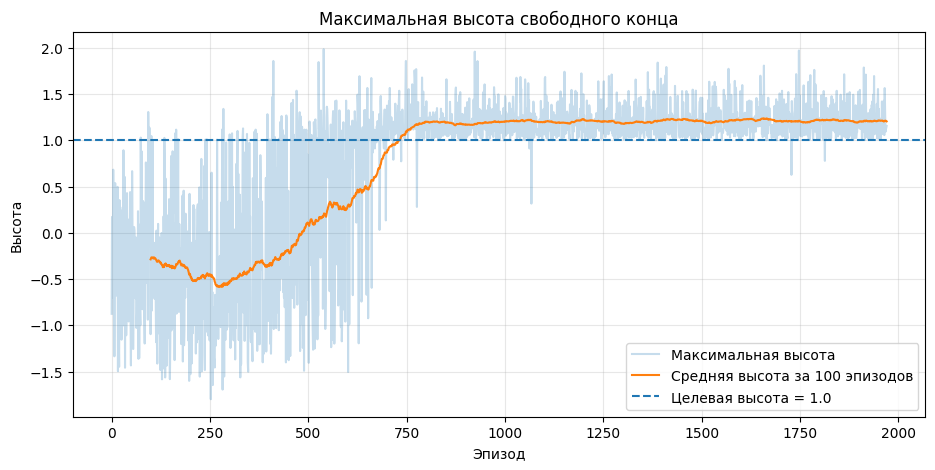

In [15]:
# Высота звена

heights = best_training[
    "heights"
]


height_ma = np.convolve(
    heights,
    np.ones(
        window
    ) / window,
    mode="valid",
)


plt.figure(
    figsize=(
        11,
        5,
    )
)


plt.plot(
    heights,
    alpha=0.25,
    label="Максимальная высота",
)


plt.plot(
    np.arange(
        window - 1,
        len(
            heights
        ),
    ),
    height_ma,
    label="Средняя высота за 100 эпизодов",
)


plt.axhline(
    1.0,
    linestyle="--",
    label="Целевая высота = 1.0",
)


plt.xlabel(
    "Эпизод"
)

plt.ylabel(
    "Высота"
)

plt.title(
    "Максимальная высота свободного конца"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

## Несколько тестовых эпизодов

Выведем результаты 10 тестовых запусков.

In [16]:
# Таблица тестовых эпизодов

test_rows = []


for index in range(
    10
):

    one_test = evaluate_policy(
        policy,
        n_episodes=1,
        seed=(
            50000
            + index
        ),
    )


    test_rows.append(
        {
            "episode": (
                index + 1
            ),

            "reward": float(
                one_test[
                    "rewards"
                ][
                    0
                ]
            ),

            "steps": int(
                one_test[
                    "steps"
                ][
                    0
                ]
            ),

            "max_height": float(
                one_test[
                    "heights"
                ][
                    0
                ]
            ),

            "success": bool(
                one_test[
                    "heights"
                ][
                    0
                ]
                > 1.0
            ),
        }
    )


test_df = pd.DataFrame(
    test_rows
)


display(
    test_df
)

,episode,reward,steps,max_height,success
0,1,-106.0,107,1.007664,True
1,2,-96.0,97,1.592344,True
2,3,-74.0,75,1.261040,True
3,4,-75.0,76,1.137158,True
4,5,-89.0,90,1.091200,True
5,6,-71.0,72,1.357447,True
6,7,-89.0,90,1.310710,True
7,8,-74.0,75,1.074754,True
8,9,-91.0,92,1.104506,True
9,10,-150.0,151,1.635081,True


## Сохранение модели

In [17]:
# Сохранение весов

torch.save(
    policy.state_dict(),
    "/content/"
    "acrobot_reinforce_policy.pt",
)


torch.save(
    value_net.state_dict(),
    "/content/"
    "acrobot_reinforce_value.pt",
)


print(
    "Модели сохранены."
)

Модели сохранены.


## Вывод

Для среды `Acrobot-v1` реализован алгоритм
**REINFORCE с baseline**.

Actor напрямую обучает стохастическую политику выбора одного из трёх
действий. В качестве baseline используется отдельная нейронная сеть,
которая оценивает ценность состояния `V(s)`.

При обновлении Actor используется преимущество:

```text
A_t = G_t - V(s_t)
```

Это уменьшает дисперсию градиента по сравнению с обычным REINFORCE.

Дополнительно в работе отслеживается фактическая высота свободного конца
второго звена. Цель считается достигнутой, если:

```text
height > 1.0
```

Качество агента проверяется на 100 новых эпизодах.
Требование задания выполнено, если:

```text
Средняя награда >= -100
```

Численный результат может немного отличаться между запусками,
поскольку REINFORCE использует стохастическую политику.